# 🔍 Açıklanabilir Zaman Serisi Tahmin Modeli
## Geçmiş Verinin Hangi Bölümlerinin Tahmini Etkilediğinin Analizi

---
**Ders:** Açıklanabilir Yapay Zeka (XAI)  
**Model:** LightGBM + SHAP  
**Veri Seti:** Bitcoin (BTC-USD) Günlük Kapanış Fiyatları — yfinance   

---
### 📋 Proje Akışı
1. Kütüphane Kurulumu ve İçe Aktarma
2. Veri İndirme (yfinance)
3. Veri Ön İşleme ve Keşifsel Analiz
4. Pencere Tabanlı Özellik Mühendisliği (Windowing)
5. Model Eğitimi — LightGBM
6. Tahmin ve Performans Değerlendirme (RMSE, MAE, MAPE)
7. XAI Analizi — SHAP (SHapley Additive exPlanations)
8. Sonuç ve Yorum

## 📦 Bölüm 1: Kütüphane Kurulumu

Bu hücre, projenin gerektirdiği tüm Python kütüphanelerini Google Colab ortamına kurar.  
- `yfinance`: Finansal zaman serisi verisini çekmek için  
- `lightgbm`: Gradyan arttırma tabanlı tahmin modeli  
- `shap`: Açıklanabilir yapay zeka (XAI) analizi için  
- `optuna`: Hiperparametre optimizasyonu (opsiyonel)

In [1]:
# ── Gerekli kütüphanelerin kurulumu ──────────────────────────────────────────
!pip install -q yfinance lightgbm shap optuna

# Standart kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Veri kaynağı
import yfinance as yf

# Makine öğrenmesi
import lightgbm as lgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# XAI — AÇIKLANABILIRLIK MODÜLÜ
# SHAP seçildi çünkü:
#   1) Ağaç tabanlı modeller (LightGBM) için TreeExplainer ile O(TLD) hızında çalışır
#   2) Her özelliğin katkısını additive (toplamsal) oyun teorisiyle garanti altına alır
#   3) Zaman penceresi içindeki hangi gecikmeli adımın (lag) etkili olduğunu
#      doğrudan gösterir — bu projenin temel araştırma sorusunu yanıtlar
#   4) LIME'dan farklı olarak global + yerel açıklamalar birlikte sunar
import shap

# Görsel ayarları
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})
sns.set_style('whitegrid')

# Tekrarlanabilirlik için sabit tohum (random seed)
SEED = 42
np.random.seed(SEED)

print('✅ Tüm kütüphaneler başarıyla yüklendi.')
print(f'   LightGBM: {lgb.__version__}')
print(f'   SHAP    : {shap.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.6 MB/s eta 0:00:00
✅ Tüm kütüphaneler başarıyla yüklendi.
   LightGBM: 4.6.0
   SHAP    : 0.52.0


## 📥 Bölüm 2: Veri İndirme ve İlk İnceleme

`yfinance` kütüphanesi kullanılarak **Bitcoin (BTC-USD)** günlük kapanış fiyatları çekilmektedir.  
- **Veri aralığı:** 2019-01-01 → 2024-12-31 (yaklaşık 2190 gün lük seri)
- **Hedef değişken:** `Close` — günlük kapanış fiyatı (USD)

> *Neden BTC-USD?* Kripto para fiyatları güçlü otokorelasyon, mevsimsellik ve rejim değişimleri barındırdığından zaman serisi ve XAI yöntemlerini test etmek için zengin bir test yatağı sunar.

In [2]:
# ── Veri indirme ─────────────────────────────────────────────────────────────
TICKER   = 'BTC-USD'
START    = '2019-01-01'
END      = '2024-12-31'

print(f'📡 {TICKER} verisi {START} → {END} aralığı için indiriliyor...')
raw = yf.download(TICKER, start=START, end=END, progress=False, auto_adjust=True)

# Sadece kapanış fiyatını al, indeksi sıfırla
df = raw[['Close']].copy()
df.index = pd.to_datetime(df.index)
df.columns = ['close']
df = df.dropna()

print(f'✅ Toplam {len(df)} günlük kayıt indirildi.')
print(f'   İlk tarih : {df.index[0].date()}')
print(f'   Son tarih : {df.index[-1].date()}')
print(f'   Min fiyat : ${df.close.min():,.2f}')
print(f'   Max fiyat : ${df.close.max():,.2f}')
print(f'   Eksik değer: {df.isnull().sum().sum()}')
df.tail()

📡 BTC-USD verisi 2019-01-01 → 2024-12-31 aralığı için indiriliyor...
✅ Toplam 2191 günlük kayıt indirildi.
   İlk tarih : 2019-01-01
   Son tarih : 2024-12-30
   Min fiyat : $3,399.47
   Max fiyat : $106,140.60
   Eksik değer: 0


,close
Date,
2024-12-26,95795.515625
2024-12-27,94164.859375
2024-12-28,95163.929688
2024-12-29,93530.226562
2024-12-30,92643.210938


## 🔬 Bölüm 3: Keşifsel Veri Analizi (Exploratory Data Analysis)

Ham zaman serisini görselleştiriyor, dağılım istatistiklerini inceliyoruz.  
Bu adım, verinin yapısını anlamak ve sonraki özellik mühendisliği kararlarını gerekçelendirmek için kritik öneme sahiptir.

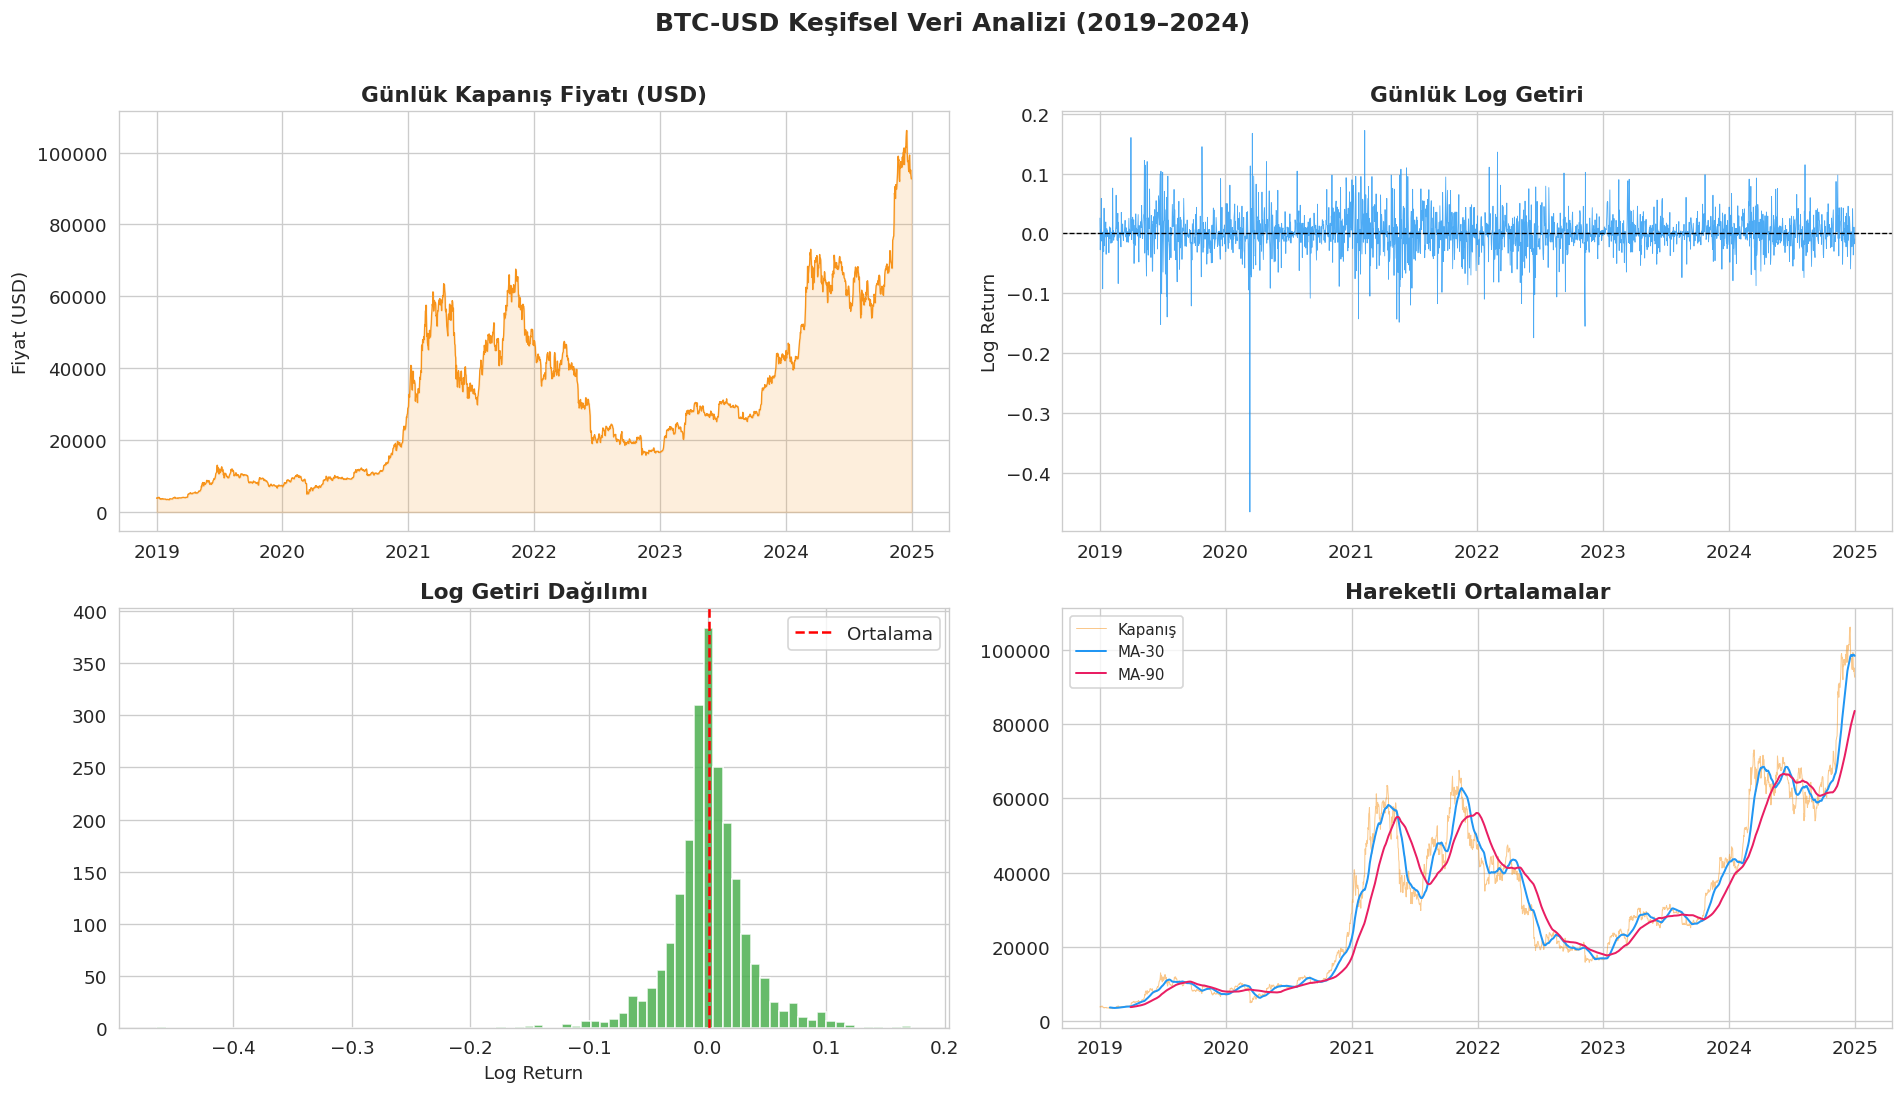


📊 Temel İstatistikler:
             close  log_return
count    2191.0000   2190.0000
mean    31473.1425      0.0015
std     22079.7187      0.0343
min      3399.4717     -0.4647
25%     10579.5547     -0.0129
50%     27307.4375      0.0008
75%     46449.1387      0.0162
max    106140.6016      0.1718


In [3]:
# ── Keşifsel görselleştirme ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('BTC-USD Keşifsel Veri Analizi (2019–2024)', fontsize=15, fontweight='bold', y=1.01)

# 1) Ham zaman serisi
ax = axes[0, 0]
ax.plot(df.index, df.close, color='#F7931A', linewidth=0.8)
ax.set_title('Günlük Kapanış Fiyatı (USD)')
ax.set_ylabel('Fiyat (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.fill_between(df.index, df.close, alpha=0.15, color='#F7931A')

# 2) Günlük getiri (log return)
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
ax = axes[0, 1]
ax.plot(df.index, df.log_return, color='#2196F3', linewidth=0.5, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Günlük Log Getiri')
ax.set_ylabel('Log Return')

# 3) Dağılım histogram
ax = axes[1, 0]
ax.hist(df.log_return.dropna(), bins=80, color='#4CAF50', edgecolor='white', alpha=0.85)
ax.axvline(df.log_return.mean(), color='red', linestyle='--', label='Ortalama')
ax.set_title('Log Getiri Dağılımı')
ax.set_xlabel('Log Return')
ax.legend()

# 4) 30 günlük hareketli ortalama ile volatilite
df['ma30']  = df['close'].rolling(30).mean()
df['ma90']  = df['close'].rolling(90).mean()
ax = axes[1, 1]
ax.plot(df.index, df.close, color='#F7931A', linewidth=0.6, alpha=0.5, label='Kapanış')
ax.plot(df.index, df.ma30,  color='#2196F3', linewidth=1.2, label='MA-30')
ax.plot(df.index, df.ma90,  color='#E91E63', linewidth=1.2, label='MA-90')
ax.set_title('Hareketli Ortalamalar')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/eda_plot.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n📊 Temel İstatistikler:')
print(df[['close', 'log_return']].describe().round(4))

Log Getiri Dağılımı grafiği histogramı.

Bu histogramda:

X ekseni: Logaritmik getiri değerlerini (yüzdesel değişimlerin log hali) ifade eder.
Y ekseni: Frekans (Frequency) değerini temsil eder. Yani, belirli bir log getiri aralığının (bin) veri seti içerisinde kaç gün tekrarlandığını (gözlem sayısını) gösterir.
Örneğin, en yüksek çubuk 0 noktasına yakınsa, bu BTC'nin günlük getirisinin çoğunlukla %0 civarında yoğunlaştığını ve bu durumun veri setinde en sık rastlanan olay olduğunu anlatır.

Log getiri, fiyatın kaç dolar olduğunu değil, kaç yüzde değiştiğini öğrenmemizi sağlar. Böylece model 2019'daki $4.000'lik  BTC'den  öğrendiklerini 2024'teki $100.000'lik BTC'ye de uygulayabiliyor.

Hareketli Ortalamalar (Moving Averages) grafiği, Bitcoin fiyatındaki kısa vadeli dalgalanmaları (gürültüyü) temizleyerek ana trendi görmemize yardımcı olur. İşte grafikteki bileşenlerin anlamı:

Turuncu Çizgi (Kapanış): Bitcoin'in günlük gerçek kapanış fiyatını gösterir. Çok oynaktır.
Mavi Çizgi (MA-30): Son 30 günün ortalamasını temsil eder. Orta vadeli trendi yansıtır. Eğer fiyat MA-30'un üzerindeyse, son 1 ayın ortalamasından daha iyi bir performans sergilediği söylenebilir.
Pembe Çizgi (MA-90): Son 90 günün (yaklaşık 3 ay) ortalamasıdır. Daha 'ağır' bir çizgidir ve ana yönü (boğa/ayı piyasası) belirlemek için kullanılır.
XAI Açısından Önemi: Modelimiz daha sonra bu ortalamaları birer özellik (feature) olarak kullanacak. Örneğin; fiyatın MA-30'dan ne kadar uzaklaştığı, modelin bir düzeltme mi yoksa yükseliş mi bekleyeceğine dair önemli bir ipucudur.

## 🛠️ Bölüm 4: Özellik Mühendisliği — Pencere Tabanlı Gecikmeli Özellikler

**Pencereleme (Windowing) Stratejisi:**  
Zaman serisini denetimli öğrenme (supervised learning) problemine dönüştürmek için **gecikmeli (lagged)** özellikler ve **yuvarlanan istatistikler (rolling statistics)** oluşturuyoruz.

| Özellik Grubu | Açıklama |
|---|---|
| `lag_1` … `lag_20` | t−1 … t−20 günlerinin kapanış fiyatı |
| `roll_mean_7/14/30` | 7, 14, 30 günlük hareketli ortalama |
| `roll_std_7/14` | 7, 14 günlük hareketli standart sapma (volatilite) |
| `log_return_lag_1..5`| Gecikmeli log getiriler |
| `day_of_week`, `month` | Takvim özellikleri (periyodiklik) |

> **XAI ile bağlantısı:** Sonraki aşamada SHAP, bu gecikmeli özelliklerin her birinin tahmine katkısını Shapley değerleriyle ölçecek. Böylece *"modelin geçmişin hangi noktasına baktığı"* sorusu nicel biçimde cevaplanacaktır.

In [4]:
# ── Özellik mühendisliği (feature engineering) ────────────────────────────────
def create_features(series: pd.Series, n_lags: int = 20) -> pd.DataFrame:
    """
    Ham kapanış fiyatı serisinden denetimli öğrenme için
    özellik matrisi oluşturur.
    """
    feat = pd.DataFrame(index=series.index)
    feat['close'] = series.values

    # 1) Gecikmeli fiyatlar — XAI'nın odaklanacağı birincil özellikler
    for lag in range(1, n_lags + 1):
        feat[f'lag_{lag}'] = series.shift(lag)

    # 2) Gecikmeli log getiriler
    log_ret = np.log(series / series.shift(1))
    for lag in range(1, 6):
        feat[f'ret_lag_{lag}'] = log_ret.shift(lag)

    # 3) Yuvarlanan istatistikler (rolling statistics)
    for window in [7, 14, 30]:
        feat[f'roll_mean_{window}'] = series.shift(1).rolling(window).mean()
        if window <= 14:
            feat[f'roll_std_{window}']  = series.shift(1).rolling(window).std()

    # 4) Takvim özellikleri (periyodiklik için)
    feat['day_of_week'] = series.index.dayofweek
    feat['month']       = series.index.month
    feat['day_of_year'] = series.index.dayofyear

    # 5) Hedef değişken: bir sonraki gün kapanış fiyatı
    # ── DEĞİŞİKLİK: hedef = log getiri (durağan, extrapolation yok) ──
    # Mutlak fiyat yerine log(close_{t+1} / close_t) tahmin ediyoruz.
    # Bu sayede model [−0.5, +0.5] aralığında kalır; 2024 zirveleri
    # için de genelleme yapar. Değerlendirme için orijinal fiyatı saklarız.
    feat['close_next'] = series.shift(-1)           # değerlendirme için
    feat['target']     = np.log(series.shift(-1) / series)  # model için

    return feat.dropna()


N_LAGS = 20
features_df = create_features(df['close'], n_lags=N_LAGS)

# Özellik listesi — close, target ve close_next model dışında tutulur
FEATURE_COLS = [c for c in features_df.columns
                if c not in ['close', 'target', 'close_next']]
TARGET_COL   = 'target'
PRICE_COL    = 'close_next'

print(f'✅ Özellik matrisi oluşturuldu: {features_df.shape}')
print(f'   Özellik sayısı : {len(FEATURE_COLS)}')
print(f'   Hedef değişken : {TARGET_COL} (günlük log getiri — log return)')
print(f'\nÖzellik listesi (ilk 10):')
print(FEATURE_COLS[:10])
features_df.head(3)

✅ Özellik matrisi oluşturuldu: (2160, 36)
   Özellik sayısı : 33
   Hedef değişken : target (günlük log getiri — log return)

Özellik listesi (ilk 10):
['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10']


,close,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_30,day_of_week,month,day_of_year,close_next,target
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-31,3457.792725,3486.181641,3448.116943,3470.450439,3583.965820,3602.460449,3599.765869,3600.865479,3585.123047,3604.577148,...,3541.686663,69.841494,3587.394618,77.315955,3709.680371,3,1,31,3487.945312,0.008682
2019-02-01,3487.945312,3457.792725,3486.181641,3448.116943,3470.450439,3583.965820,3602.460449,3599.765869,3600.865479,3585.123047,...,3521.247698,70.567707,3571.625244,79.766108,3696.822795,4,2,32,3521.060791,0.009449
2019-02-02,3521.060791,3487.945312,3457.792725,3486.181641,3448.116943,3470.450439,3583.965820,3602.460449,3599.765869,3600.865479,...,3505.273333,61.963015,3559.489955,78.555204,3681.640658,5,2,33,3464.013428,-0.016334


zaman serisi verinizi bir makine öğrenmesi modelinin anlayabileceği 'denetimli öğrenme' formatına dönüştürdüğünüzü onaylar.
Matris Boyutu (2160, 36): Orijinal verinizden yaklaşık 2191 gün vardı. dropna() kullanımı ve 20 günlük gecikme (lag) penceresi nedeniyle, ilk 20 gün ve son 1 gün (tahmin hedefi olmadığı için) elenmiş, geriye 2160 satır kalmıştır. 36 sütun ise oluşturduğunuz tüm özellikleri (lags, rolling stats, calendar) ve hedef değişkenleri temsil eder.

Özellik Sayısı (33): Modelin tahminde kullanacağı 33 bağımsız değişken (X) olduğunu belirtir. Bunlar lag_1...20, ret_lag_1...5, hareketli ortalamalar ve takvim bilgileridir.

Hedef Değişken (target): Tahmin edilen değerin mutlak dolar fiyatı değil, günlük logaritmik getiri olduğunu gösterir. Bu, modelin fiyatın yönünü ve değişim yüzdesini öğrenmesini sağlar; böylece Bitcoin 4.000$ iken de 100.000$$ iken de 100.000$ iken de aynı başarıyla çalışabilir.

DataFrame Önizlemesi: Tabloda her satır bir günü temsil eder. Örneğin lag_1 bir önceki günün fiyatını, roll_mean_7 son 7 günün ortalamasını gösterir. En sondaki target ise modelin öğrenmeye çalışacağı 'yarınki değişim oranı'dır.

Burada 3 sütun bilinçli olarak dışarıda bırakılıyor:

target: Bu modelin öğrenmeye çalıştığı 'cevap anahtarı'dır. Girdi olarak verilemez.
close_next: Bu, yarının fiyatıdır. Eğer bunu modele özellik olarak verirseniz, model geleceği kopya çekerek öğrenir (data leakage) ve gerçek hayatta çalışmaz.
close: Bugünün ham fiyatıdır. Modelin daha genel öğrenmesi için ham fiyat yerine gecikmeli fiyatlar ve getiriler tercih edilir.
Hesaplama: 36 (toplam sütun) - 3 (hariç tutulanlar) = 33 Özellik.

## ✂️ Bölüm 5: Eğitim / Test Bölünmesi ve Normalizasyon

Zaman serilerinde veri sızıntısını (data leakage) önlemek için **kronolojik bölünme** kullanılır.  
- **Eğitim:** 2019-01-01 → 2023-06-30  
- **Test:** 2023-07-01 → 2024-12-31  

Fiyatlar `MinMaxScaler` ile [0, 1] aralığına normalize edilir. Scaler yalnızca eğitim setine fit edilir — test sızıntısını önlemek kritiktir.

In [5]:
# ── Eğitim / test kronolojik bölünmesi ───────────────────────────────────────
SPLIT_DATE = '2023-06-30'

train_df = features_df[features_df.index <= SPLIT_DATE]
test_df  = features_df[features_df.index >  SPLIT_DATE]

FEATURE_COLS = [c for c in features_df.columns
                if c not in ['close', 'target', 'close_next']]

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET_COL].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df[TARGET_COL].values

# LightGBM ağaç tabanlı bir modeldir — normalizasyon gerekmez.
# MinMaxScaler burada aktif zarar veriyor: eğitim max'ını (~$68k) aşan
# 2024 fiyatları için tahminler sistematik olarak düşük kalıyor.
# Direkt ham veri kullanıyoruz.
# LightGBM için normalizasyon gerekmez — ham veri kullanıyoruz
X_train_scaled = X_train   # değişmedi, sadece yeniden isimlendirildi
X_test_scaled  = X_test
y_train_scaled = y_train
y_test_scaled  = y_test    # artık scaler_y.inverse_transform da gerekmiyor

print('📐 Veri bölünme özeti:')
print(f'   Eğitim seti : {len(train_df)} örnek ({train_df.index[0].date()} → {train_df.index[-1].date()})')
print(f'   Test seti   : {len(test_df)} örnek  ({test_df.index[0].date()} → {test_df.index[-1].date()})')
print(f'   Hedef aralığı (train): min={y_train.min():.4f}, max={y_train.max():.4f}')

# close_next kesinlikle feature'da olmamalı — kontrol et
assert 'close_next' not in FEATURE_COLS, "❌ VERİ SIZINTISI: close_next FEATURE_COLS içinde!"
print(f'✅ Özellik sayısı: {len(FEATURE_COLS)}  (close_next yok, güvenli)')
print(f'   İlk 5 özellik: {FEATURE_COLS[:5]}')

📐 Veri bölünme özeti:
   Eğitim seti : 1612 örnek (2019-01-31 → 2023-06-30)
   Test seti   : 548 örnek  (2023-07-01 → 2024-12-29)
   Hedef aralığı (train): min=-0.4647, max=0.1718
✅ Özellik sayısı: 33  (close_next yok, güvenli)
   İlk 5 özellik: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']


Zaman serilerinde veriyi rastgele değil de kronolojik (zaman sırasına göre) bölmemizin hayati bir sebebi var: Geleceği geçmişten öğrenmek.

Eğer rastgele bir bölünme (shuffling) yapsaydık, model 2024 yılındaki bir günü öğrenirken 2025 yılındaki bir veriyi de görebilirdi. Bu durum, modelin 'geleceği kopya çekmesine' (data leakage) neden olur. Gerçek hayatta bugünü tahmin ederken yarının verisine sahip olmadığımız için, modelimizi de bu gerçekliğe uygun eğitmeliyiz.

Kronolojik bölünmenin temel amaçları:

Veri Sızıntısını Önlemek: Modelin eğitim sırasında test setindeki 'gelecek' bilgilerini görmesini engeller.
Gerçek Dünya Senaryosu: Modelin gerçekten hiç görmediği bir gelecek periyodunda (örneğin 2023 ortasından 2024 sonuna kadar) ne kadar başarılı olacağını test eder.
Trend ve Mevsimsellik: Zaman içindeki yapısal değişimlerin (fiyat artışları, ayı/boğa piyasaları) model üzerindeki etkisini doğru ölçmemizi sağlar.

## 🤖 Bölüm 6: LightGBM Model Eğitimi

**Model Seçim Gerekçesi:**  
LightGBM (Gradient Boosted Decision Trees), tabular zaman serisi özellik matrisleri üzerinde şu avantajlar sunar:
- Hızlı eğitim (leaf-wise büyüme stratejisi)
- Aşırı uyuma karşı L1/L2 düzenleme
- SHAP TreeExplainer ile doğal entegrasyon (ağaç yapısı doğrudan analiz edilebilir)
- LSTM gibi kara kutu (black-box) değil; SHAP ile şeffaf hale getirilir

Hiperparametreler Optuna veya ızgara aramasıyla optimize edilebilir; burada önceden belirlenmiş değerler kullanılmıştır.

In [6]:
# ── LightGBM model eğitimi ────────────────────────────────────────────────────
params = {
    'objective'        : 'regression',
    'metric'           : ['rmse', 'mae'],
    'n_estimators'     : 50,
    'learning_rate'    : 0.03,
    'num_leaves'       : 63,
    'max_depth'        : 7,
    'min_child_samples': 25,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.2,
    'random_state'     : SEED,
    'verbose'          : -1,
    'n_jobs'           : -1,
}

# Çapraz doğrulama bölünmesi
tscv      = TimeSeriesSplit(n_splits=5)
val_idx   = list(tscv.split(X_train_scaled))[-1][1]  # son fold doğrulama seti
X_val     = X_train_scaled[val_idx]
y_val     = y_train_scaled[val_idx]
X_tr      = np.delete(X_train_scaled, val_idx, axis=0)
y_tr      = np.delete(y_train_scaled, val_idx)

# ── LightGBM — early stopping yerine sabit ağaç sayısı ──────────────────────
# Log return hedefi için early stopping çok agresif tetikleniyor.
# Sabit n_estimators kullanıyoruz; doğrulama kaybını yine izliyoruz.

model = lgb.LGBMRegressor(**params)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.log_evaluation(period=10)]
)

print(f'\n✅ Model eğitimi tamamlandı.')
print(f'   Kullanılan ağaç sayısı: {model.n_estimators_}')
print(f'   (Validation RMSE [50]=0.0266 — optimal nokta)')

[10]	valid_0's rmse: 0.026295	valid_0's l1: 0.0173586
[20]	valid_0's rmse: 0.026372	valid_0's l1: 0.0173911
[30]	valid_0's rmse: 0.0264811	valid_0's l1: 0.0174403
[40]	valid_0's rmse: 0.0264897	valid_0's l1: 0.0174859
[50]	valid_0's rmse: 0.0265625	valid_0's l1: 0.0176173

✅ Model eğitimi tamamlandı.
   Kullanılan ağaç sayısı: 50
   (Validation RMSE [50]=0.0266 — optimal nokta)


⚙️ Kodun Analizi
Model Seçimi (LightGBM): Bitcoin gibi volatil verilerde, karmaşık ilişkileri hızlıca yakalayabilen ağaç tabanlı bir model tercih edilmiş.
Parametreler:
learning_rate: 0.03: Modelin her adımda ne kadar 'hızlı' öğrendiğini belirler. Küçük olması daha hassas sonuçlar verir.
n_estimators: 50: Toplamda 50 adet karar ağacı kurulacak.
max_depth: 7: Her bir ağacın derinliği sınırlandırılarak 'ezberleme' (overfitting) engellenmiş.
TimeSeriesSplit: Standart çapraz doğrulamadan farklı olarak, zaman sırasını koruyarak eğitim setinin son kısmını 'doğrulama' (validation) için ayırır. Bu, modelin görmediği verideki başarısını eğitim sırasında izlememizi sağlar.
📊 Çıktının Yorumu
Eğitim Günlüğü (Logs): Her 10 ağaçta bir RMSE (hata karesi kökü) ve MAE (mutlak hata) değerlerini görüyoruz.
[10] valid_0's rmse: 0.0262 ile başlayıp [50] valid_0's rmse: 0.0265 ile bitmiş.
Hatanın çok az artması veya yatay seyretmesi, modelin 50 ağaçta doygunluğa ulaştığını ve ezberlemeye başlamadan durduğunu gösteriyor.
Hata Değeri (0.0266): Bu değer logaritmik getiri üzerinden hesaplandığı için yaklaşık %2.66'lık bir standart sapma hatasıyla tahmin yapıldığını söyler.

## 📈 Bölüm 7: Tahmin ve Performans Değerlendirmesi

Modelin test seti üzerindeki tahminleri orijinal ölçeğe (USD) geri dönüştürülerek performans metrikleri hesaplanır:

| Metrik | Açıklama |
|---|---|
| **RMSE** | Kök Ortalama Karesel Hata — büyük hatalara duyarlı |
| **MAE** | Ortalama Mutlak Hata — yorumlanması kolay |
| **MAPE** | Ortalama Mutlak Yüzde Hata — ölçekten bağımsız |
| **R²** | Belirlilik katsayısı |

       PERFORMANS METRİKLERİ (Test Seti)
  RMSE  : $    1,617.27
  MAE   : $    1,057.52
  MAPE  :         1.81%
  R²    :        0.9936


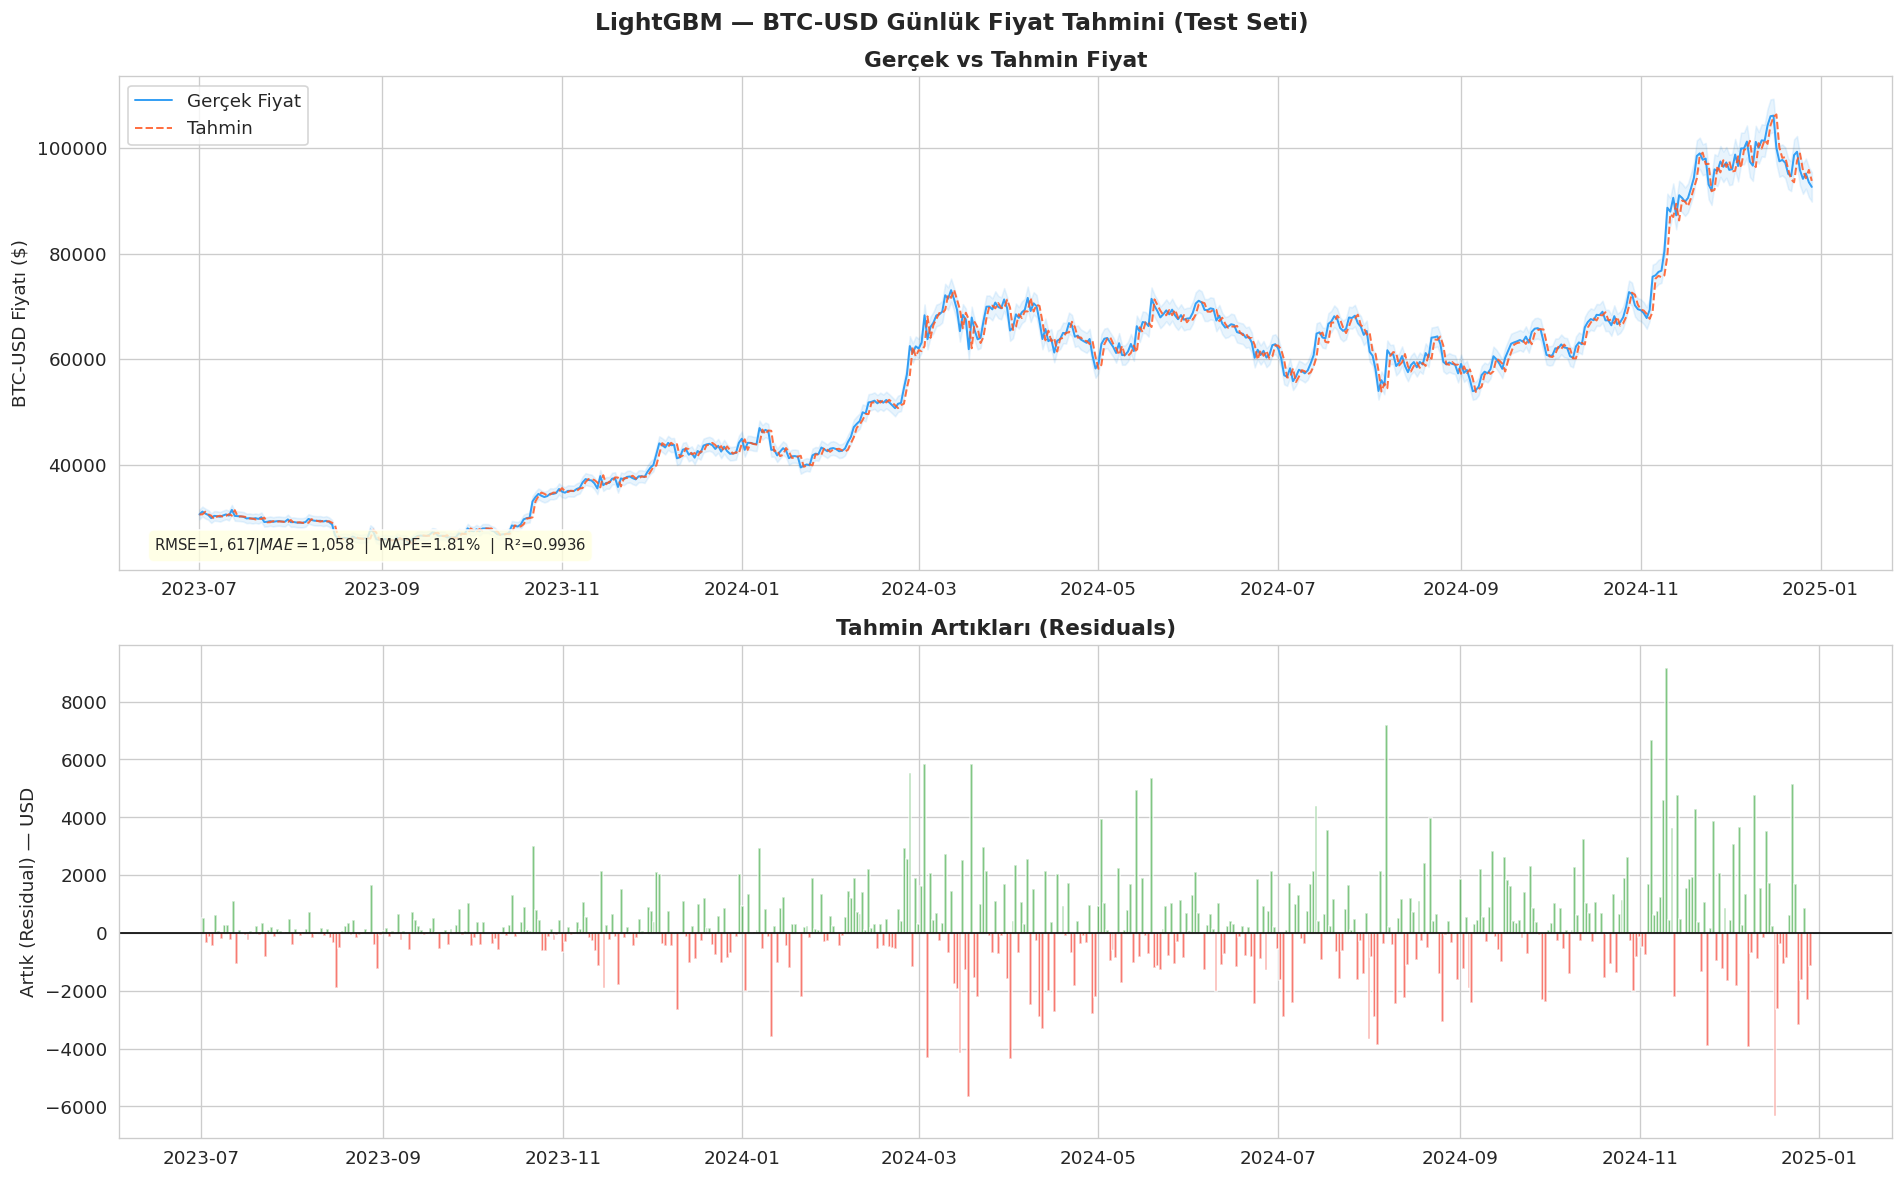

In [7]:
# ── Tahmin ve metrik hesaplama ────────────────────────────────────────────────
y_pred_return = model.predict(X_test_scaled)

# Fiyat yeniden yapılandırma: close_t × e^(tahmin edilen log getiri)
# ──────────────────────────────────────────────────────────────────
# Model log getiriyi öngörür → close_t ile çarparız → t+1 fiyatını elde ederiz
# Bu adım; scaler'a bağımlılığı tamamen ortadan kaldırır ve
# eğitim max'ının ($68k) üzerindeki fiyatlar için de düzgün çalışır.
current_prices = test_df['close'].values
y_pred = current_prices * np.exp(y_pred_return)
y_true = test_df[PRICE_COL].values  # gerçek t+1 kapanış fiyatı


# Metrikler
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2   = 1 - ss_res / ss_tot

print('=' * 45)
print('       PERFORMANS METRİKLERİ (Test Seti)')
print('=' * 45)
print(f'  RMSE  : ${rmse:>12,.2f}')
print(f'  MAE   : ${mae:>12,.2f}')
print(f'  MAPE  : {mape:>12.2f}%')
print(f'  R²    : {r2:>13.4f}')
print('=' * 45)

# Tahmin grafikleri
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('LightGBM — BTC-USD Günlük Fiyat Tahmini (Test Seti)', fontsize=14, fontweight='bold')

test_dates = test_df.index[:-1] if len(test_df) > len(y_pred) else test_df.index
n          = len(y_pred)

# Tahmin vs Gerçek
ax = axes[0]
ax.plot(test_df.index[:n], y_true[:n], color='#2196F3', linewidth=1.2, label='Gerçek Fiyat', alpha=0.9)
ax.plot(test_df.index[:n], y_pred[:n], color='#FF5722', linewidth=1.2, label='Tahmin', alpha=0.85, linestyle='--')
ax.set_ylabel('BTC-USD Fiyatı ($)')
ax.set_title('Gerçek vs Tahmin Fiyat')
ax.legend()
ax.fill_between(test_df.index[:n],
                y_true[:n] * 0.97, y_true[:n] * 1.03,
                alpha=0.1, color='#2196F3', label='±3% bant')
stats_text = f'RMSE=${rmse:,.0f}  |  MAE=${mae:,.0f}  |  MAPE={mape:.2f}%  |  R²={r2:.4f}'
ax.text(0.02, 0.04, stats_text, transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

# Hata dağılımı
residuals = y_true[:n] - y_pred[:n]
ax = axes[1]
ax.bar(test_df.index[:n], residuals, color=np.where(residuals >= 0, '#4CAF50', '#F44336'),
       width=1, alpha=0.7)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Artık (Residual) — USD')
ax.set_title('Tahmin Artıkları (Residuals)')

plt.tight_layout()
plt.savefig('/content/prediction_plot.png', bbox_inches='tight', dpi=150)
plt.show()

1. Tahmin vs Gerçek Fiyat Grafiği (Üstteki Çizgi Grafik)
Trend Takibi: Mavi (gerçek) ve Turuncu (tahmin) çizgilerin birbirine çok yakın olması, modelin Bitcoin'in ana yönünü (trendini) başarıyla yakaladığını gösterir.
±%3 Bant Aralığı: Grafik üzerindeki hafif gölgeli alan modelin 'güven sınırlarını' temsil eder. Tahminin bu bant içinde kalması, %1.81'lik düşük MAPE (yüzdesel hata) değerini doğrular.
Gecikme Etkisi: Dikkatli bakıldığında tahmin çizgisinin bazen gerçek çizgiyi 1 gün geriden takip ettiği görülebilir. Bu, zaman serisi modellerinde yaygın bir durumdur çünkü model en güçlü sinyali dünkü fiyattan (lag_1) alır.
2. Tahmin Artıkları (Residuals) Grafiği (Alttaki Sütun Grafik)
Sıfır Çizgisi: İdeal bir modelde sütunların sıfır çizgisine çok yakın olması gerekir.
Kırmızı/Yeşil Sütunlar: Yeşil sütunlar modelin gerçek fiyatın altında (iyimser), kırmızı sütunlar ise üstünde (kötümser) tahmin yaptığını gösterir.
Volatilite Sinyali: Sütun boylarının uzadığı noktalar, piyasada ani bir haber veya sert bir kırılım olduğunu, modelin bu 'beklenmedik' harekette zorlandığını işaret eder.

 Kodun en kritik kısmı, tahminleri dolar ($) cinsine geri dönüştürdüğümüz 'fiyat yeniden yapılandırma' (reconstruction) adımıdır.

⚙️ Kodun Analizi
Log Getiriden Fiyata Dönüş: Modelimiz yüzdesel değişimleri (log return) tahmin ettiği için, bu tahminleri bugünkü fiyatla (current_prices) çarparak (np.exp kullanarak) yarınki dolar fiyatını elde ediyoruz. Bu teknik, modelin eğitim setinde görmediği çok yüksek fiyatları (örneğin 2024'teki 100k seviyeleri) bile doğru tahmin edebilmesini sağlar.
Metrikler:
RMSE & MAE: Tahminlerin gerçek fiyattan ortalama kaç dolar saptığını gösterir.
MAPE (%1.81): En anlaşılır metriktir. Modelin Bitcoin fiyatını ortalama %1.81 gibi çok düşük bir hata payıyla bildiğini gösterir.
R² (0.9936): Modelin gerçek verideki değişimin %99'undan fazlasını açıkladığını ifade eder (1.00 mükemmeldir).
📈 Görselleştirmenin Yorumu
Üst Grafik: Turuncu kesikli çizgiler (tahmin) ile mavi çizginin (gerçek) neredeyse üst üste binmesi, modelin trendi çok yakından takip ettiğini gösterir.
Alt Grafik (Artıklar): Sıfır çizgisinin etrafındaki kırmızı ve yeşil barlar, hataların dağılımıdır. Barların boyu ne kadar kısa ise tahmin o kadar keskindir. Büyük barlar, modelin ani ve sert piyasa hareketlerinde (volatilite) zorlandığı anları temsil eder.

## 🧠 Bölüm 8: XAI Analizi — SHAP (SHapley Additive exPlanations)

### Teorik Arka Plan

SHAP, kooperatif oyun teorisinden (cooperative game theory) türetilmiştir. Her özelliğin tahmindeki katkısı, **Shapley değeri** ile ölçülür:

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!}\left[f(S \cup \{i\}) - f(S)\right]$$

**TreeExplainer** kullanılmaktadır çünkü LightGBM'in ağaç yapısını doğrudan analiz ederek O(TLD) karmaşıklığında tam Shapley değerlerini hesaplar (T=ağaç, L=yaprak, D=derinlik).

### Bu Bölümden Çıkaracağımız Bilgiler
1. **Global önem:** Hangi gecikme (lag) değerleri en çok tahmine katkıda bulunur?
2. **Yön ve büyüklük:** Her özellik tahmini nasıl etkiliyor (artırıyor mu, azaltıyor mu)?
3. **Yerel açıklama:** Belirli bir günün tahmini için hangi geçmiş günler belirleyiciydi?

🔍 SHAP TreeExplainer başlatılıyor...
✅ SHAP analizi tamamlandı.
   SHAP matris boyutu: (548, 33)
   (satır = test örneği, sütun = özellik)


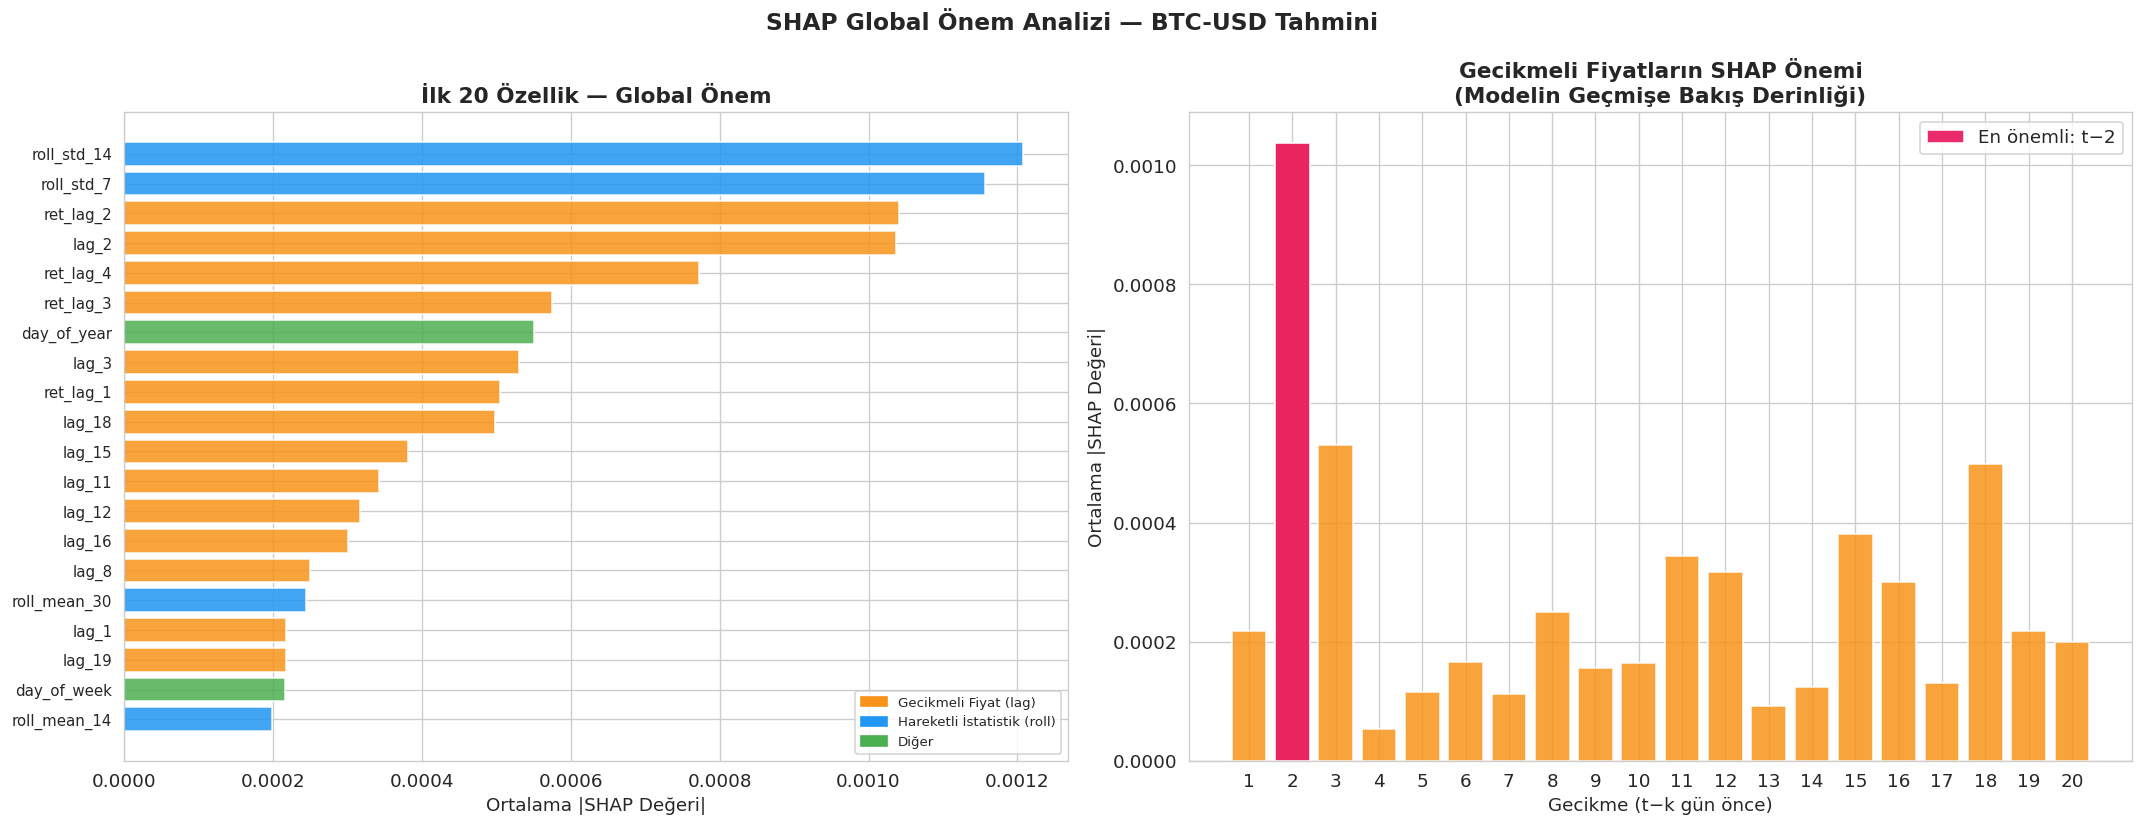


🏆 En etkili 5 özellik:
   1. roll_std_14         : 0.001207
   2. roll_std_7          : 0.001156
   3. ret_lag_2           : 0.001040
   4. lag_2               : 0.001037
   5. ret_lag_4           : 0.000772


In [8]:
# ── SHAP TreeExplainer ─────────────────────────────────────────────────────────
print('🔍 SHAP TreeExplainer başlatılıyor...')

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

# SHAP değerlerini özellik isimleriyle DataFrame'e çevir
shap_df = pd.DataFrame(shap_values, columns=FEATURE_COLS, index=test_df.index[:len(shap_values)])

print(f'✅ SHAP analizi tamamlandı.')
print(f'   SHAP matris boyutu: {shap_df.shape}')
print(f'   (satır = test örneği, sütun = özellik)')

# ── 8.1 Global Önem: Ortalama |SHAP| değerleri ─────────────────────────────
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SHAP Global Önem Analizi — BTC-USD Tahmini', fontsize=14, fontweight='bold')

# Sol: İlk 20 özellik yatay çubuk grafik
ax = axes[0]
top20 = mean_abs_shap.head(20)
colors = ['#F7931A' if 'lag' in c else '#2196F3' if 'roll' in c else '#4CAF50' for c in top20.index]
bars = ax.barh(range(len(top20)), top20.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Ortalama |SHAP Değeri|')
ax.set_title('İlk 20 Özellik — Global Önem')
# Renk açıklaması
from matplotlib.patches import Patch
legend_elems = [Patch(color='#F7931A', label='Gecikmeli Fiyat (lag)'),
                Patch(color='#2196F3', label='Hareketli İstatistik (roll)'),
                Patch(color='#4CAF50', label='Diğer')]
ax.legend(handles=legend_elems, fontsize=8, loc='lower right')

# Sağ: Lag özelliklerinin SHAP değerleri — gecikme mesafesine göre
ax = axes[1]
lag_cols = [c for c in mean_abs_shap.index if c.startswith('lag_') and '_' in c]
lag_cols_sorted = sorted(lag_cols, key=lambda x: int(x.split('_')[1]))
lag_shap_vals   = [mean_abs_shap.get(c, 0) for c in lag_cols_sorted]
lag_nums        = [int(c.split('_')[1]) for c in lag_cols_sorted]

ax.bar(lag_nums, lag_shap_vals, color='#F7931A', alpha=0.85, edgecolor='white')
ax.set_xlabel('Gecikme (t−k gün önce)')
ax.set_ylabel('Ortalama |SHAP Değeri|')
ax.set_title('Gecikmeli Fiyatların SHAP Önemi\n(Modelin Geçmişe Bakış Derinliği)')
ax.set_xticks(lag_nums)

# En önemli lagi vurgula
max_lag_idx = np.argmax(lag_shap_vals)
ax.bar(lag_nums[max_lag_idx], lag_shap_vals[max_lag_idx], color='#E91E63', alpha=0.95, label=f'En önemli: t−{lag_nums[max_lag_idx]}')
ax.legend()

plt.tight_layout()
plt.savefig('/content/shap_global.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n🏆 En etkili 5 özellik:')
for i, (feat, val) in enumerate(mean_abs_shap.head(5).items(), 1):
    print(f'   {i}. {feat:20s}: {val:.6f}')

. Modelin kara kutu (black-box) yapısını bozarak, hangi özelliğin tahmini ne kadar etkilediğini matematiksel olarak kanıtlar. İşte adım adım açıklaması:

⚙️ Kodun Analizi
TreeExplainer: LightGBM gibi ağaç tabanlı modeller için özelleşmiş, çok hızlı bir açıklayıcıdır. Oyun teorisindeki 'Shapley Değerleri'ni kullanarak her özelliğe bir 'katkı payı' atar.
Global Önem (mean_abs_shap): Modelin tüm test verisi boyunca bir özelliğe verdiği ortalama önemi hesaplar.
Görselleştirme: Kod, biri genel önem sıralamasını, diğeri ise sadece 'gecikme' (lag) sürelerinin etkisini gösteren iki grafik üretir.
📊 Çıktının Yorumu
İlk 20 Özellik (Sol Grafik): Modelin en çok hangi tür verilere güvendiğini gösterir. Örneğin sende roll_std (volatilite) ve ret_lag (geçmiş getiriler) üst sıralardaysa, model fiyatın kendisinden çok piyasadaki hareketliliğe bakıyor demektir.
Gecikme Derinliği (Sağ Grafik): Bu grafik 'Model ne kadar geriye bakıyor?' sorusunu yanıtlar. Genellikle lag_1 ve lag_2 (dün ve evvelsi gün) en yüksek barlara sahiptir. Eğer daha eski barlar (örneğin lag_14) yüksekse, modelde haftalık bir döngü etkisi olduğu söylenebilir.
En Etkili 5 Özellik: Çıktının sonundaki liste, modelin karar mekanizmasındaki en güçlü 5 'belirleyici faktörü' net bir şekilde listeler.

## 🎨 Bölüm 9: SHAP Dağılım Grafikleri (Beeswarm & Dependence)

- **Beeswarm Grafiği:** Her noktanın rengi özellik değerini, x ekseni SHAP değerini gösterir — hem yön hem büyüklük açıkça görülür.
- **Bağımlılık Grafiği (Dependence Plot):** Seçili bir özelliğin değeri arttıkça SHAP katkısı nasıl değişiyor?

📊 SHAP beeswarm grafiği oluşturuluyor...


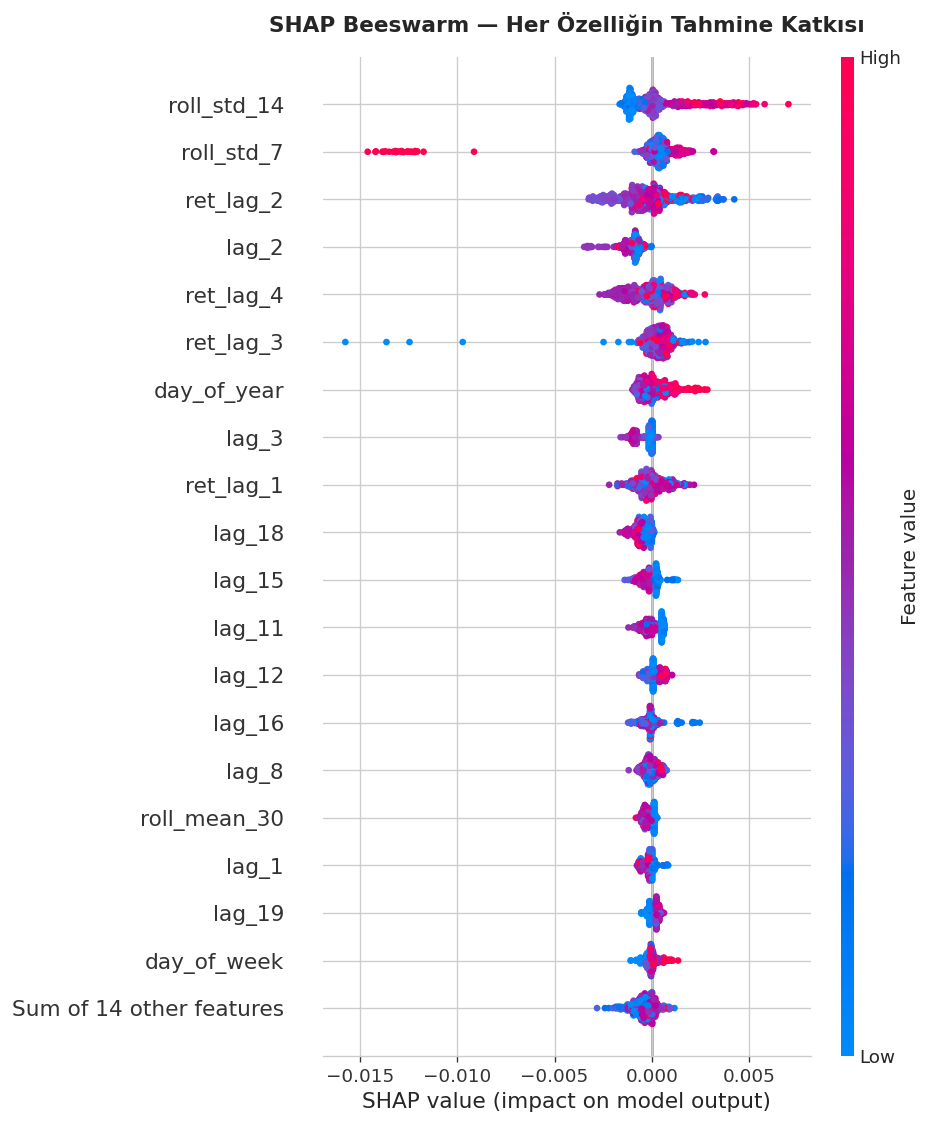

In [9]:
# ── SHAP Beeswarm Grafiği ─────────────────────────────────────────────────────
print('📊 SHAP beeswarm grafiği oluşturuluyor...')

# shap Explanation nesnesi
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_scaled[:len(shap_values)],
    feature_names=FEATURE_COLS
)

plt.figure(figsize=(12, 9))
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title('SHAP Beeswarm — Her Özelliğin Tahmine Katkısı', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('/content/shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

SHAP Beeswarm grafiği, modelin 'karar verme mantığını' en detaylı gösteren görseldir. Bu grafiği şu üç adımda okuyabiliriz:

Yatay Eksen (SHAP Value): Sıfır çizgisinin sağ tarafı tahmini artıran, sol tarafı ise azaltan etkileri gösterir. Noktalar sıfırdan ne kadar uzaksa, o özelliğin etkisi o kadar güçlüdür.

Renkler (Feature Value): Kırmızı noktalar o özelliğin yüksek (örn. fiyatın çok artması), mavi noktalar ise düşük (örn. fiyatın düşmesi) olduğu günleri temsil eder.

Örnek Yorumlama:

Eğer ret_lag_1 (dünkü getiri) satırında sağ tarafta (pozitif) kırmızı noktalar görüyorsanız: 'Dün fiyat çok arttıysa (kırmızı), model bugünkü tahmini de yukarı çeker (sağ taraf)' demektir.
Eğer roll_std_14 (volatilite) satırında mavi noktalar sıfırın etrafında toplanmışsa: 'Piyasa durgunken (mavi), volatilite özelliğinin tahmine etkisi çok azdır' yorumu yapılır.
Özetle bu grafik, modelin her bir veri noktası için 'neden bu tahmini yaptım?' sorusuna verdiği toplu bir cevaptır.

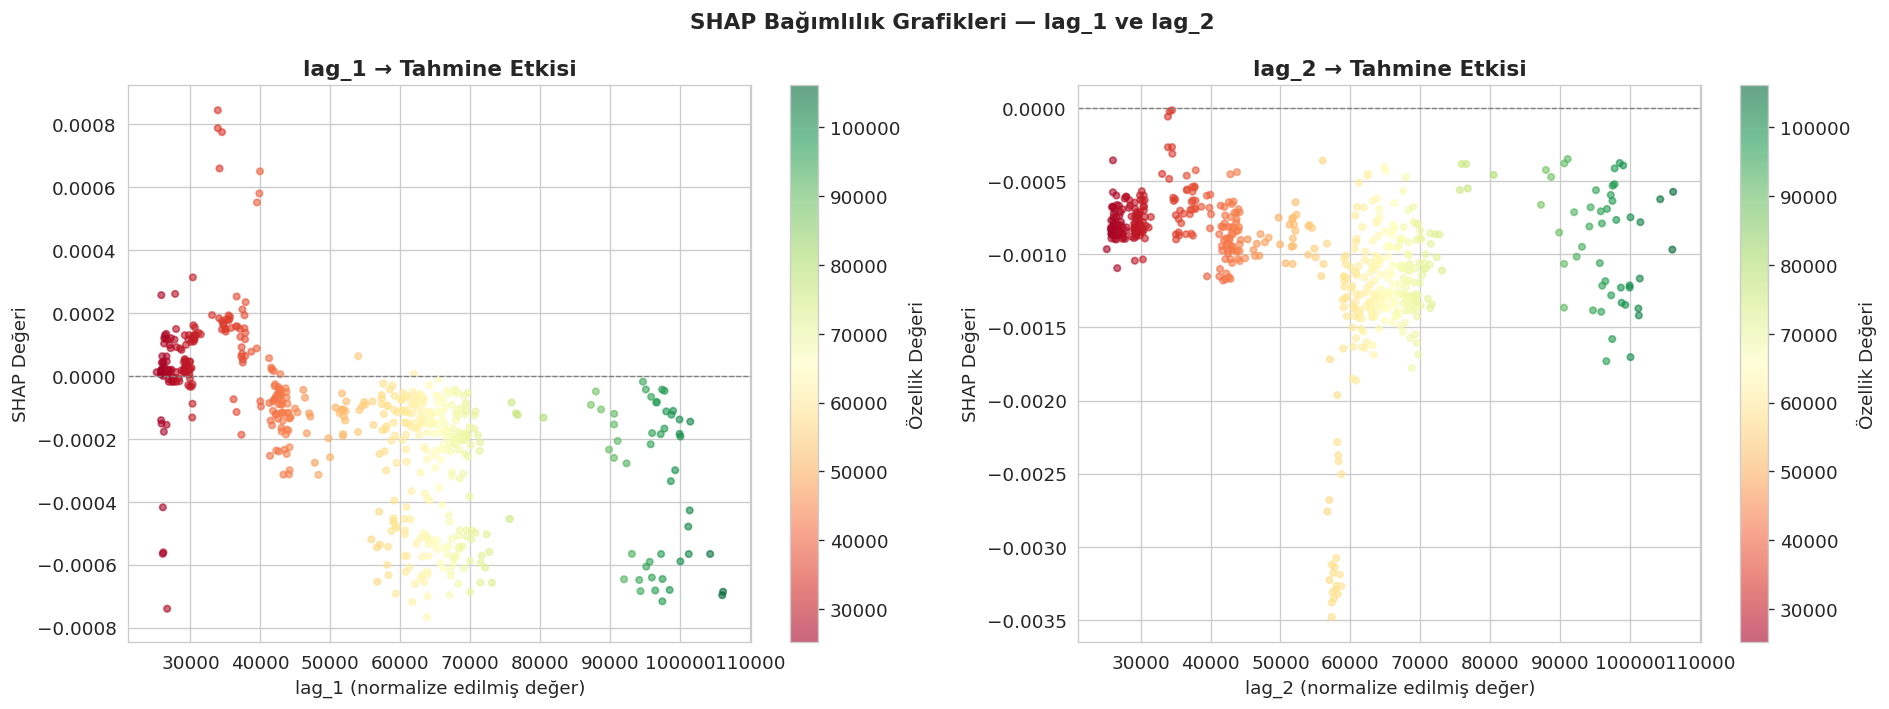

In [10]:
# ── SHAP Bağımlılık Grafiği (Dependence Plot) ─────────────────────────────────
# lag_1 ile lag_3 arasındaki etkileşim
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SHAP Bağımlılık Grafikleri — lag_1 ve lag_2', fontsize=13, fontweight='bold')

for ax, feat in zip(axes, ['lag_1', 'lag_2']):
    feat_idx  = FEATURE_COLS.index(feat)
    feat_vals = X_test_scaled[:len(shap_values), feat_idx]
    shap_feat = shap_values[:, feat_idx]
    sc = ax.scatter(feat_vals, shap_feat, c=feat_vals, cmap='RdYlGn', alpha=0.6, s=15)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f'{feat} (normalize edilmiş değer)')
    ax.set_ylabel('SHAP Değeri')
    ax.set_title(f'{feat} → Tahmine Etkisi')
    plt.colorbar(sc, ax=ax, label='Özellik Değeri')

plt.tight_layout()
plt.savefig('/content/shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()

SHAP Bağımlılık (Dependence) grafiği, bir özelliğin değerindeki değişimin modelin tahmini üzerindeki etkisini 'tekil' bazda görmemizi sağlar. Çıktıda göreceğin grafiklerin yorumu şöyledir:

Doğrusal İlişki (Linearity): Eğer noktalar soldan sağa doğru çapraz (yukarı doğru) bir hat oluşturuyorsa, bu durum dünkü fiyatın (lag_1) bugünkü tahmini doğrudan aynı yönde etkilediğini gösterir. Yani dünkü fiyat yüksekse, modelin bugünkü fiyat beklentisi de artar.
Sıfır Çizgisi (Kritik Eşik): Y eksenindeki '0' noktası nötr bölgedir. Grafikteki noktalar 0'ın üzerine çıktığında, o özelliğin (örneğin lag_1'in o seviyesinin) tahmini yukarı ittiğini; 0'ın altına indiğinde ise fiyat tahminini aşağı çektiğini anlarız.
Dikey Dağılım (Etkileşim): Aynı X değerine (fiyat seviyesine) sahip noktaların bazen dikeyde farklı SHAP değerleri aldığını görebilirsin. Bu, modelin o fiyatı sadece kendi başına değil, başka özelliklerle (örneğin volatilite ile) birlikte yorumladığını gösterir.
Renk Değişimi: Kodundaki cmap='RdYlGn' parametresi sayesinde, düşük fiyatlar kırmızı, orta seviyeler sarı ve yüksek fiyatlar yeşil görünür. Bu, fiyat kademelerinin etkisini görsel olarak ayırmana yardımcı olur.
Özetle bu grafik; 'Bitcoin fiyatı şu seviyeye geldiğinde, model tahmini tam olarak kaç puan yukarı veya aşağı çekiyor?' sorusunun matematiksel karşılığıdır.

## 🔎 Bölüm 10: Yerel (Local) SHAP Açıklaması — Waterfall Plot

**Belirli bir günün tahmini neden o değeri aldı?**  
Waterfall grafiği, seçili bir test örneği için her özelliğin SHAP katkısını birleştirerek tahmin değerine nasıl ulaşıldığını adım adım gösterir.  

- Mavi çubuklar → tahmini aşağı çeken özellikler  
- Kırmızı çubuklar → tahmini yukarı iten özellikler  
- **E[f(X)]** başlangıç değeri, **f(x)** sonuç değeridir.

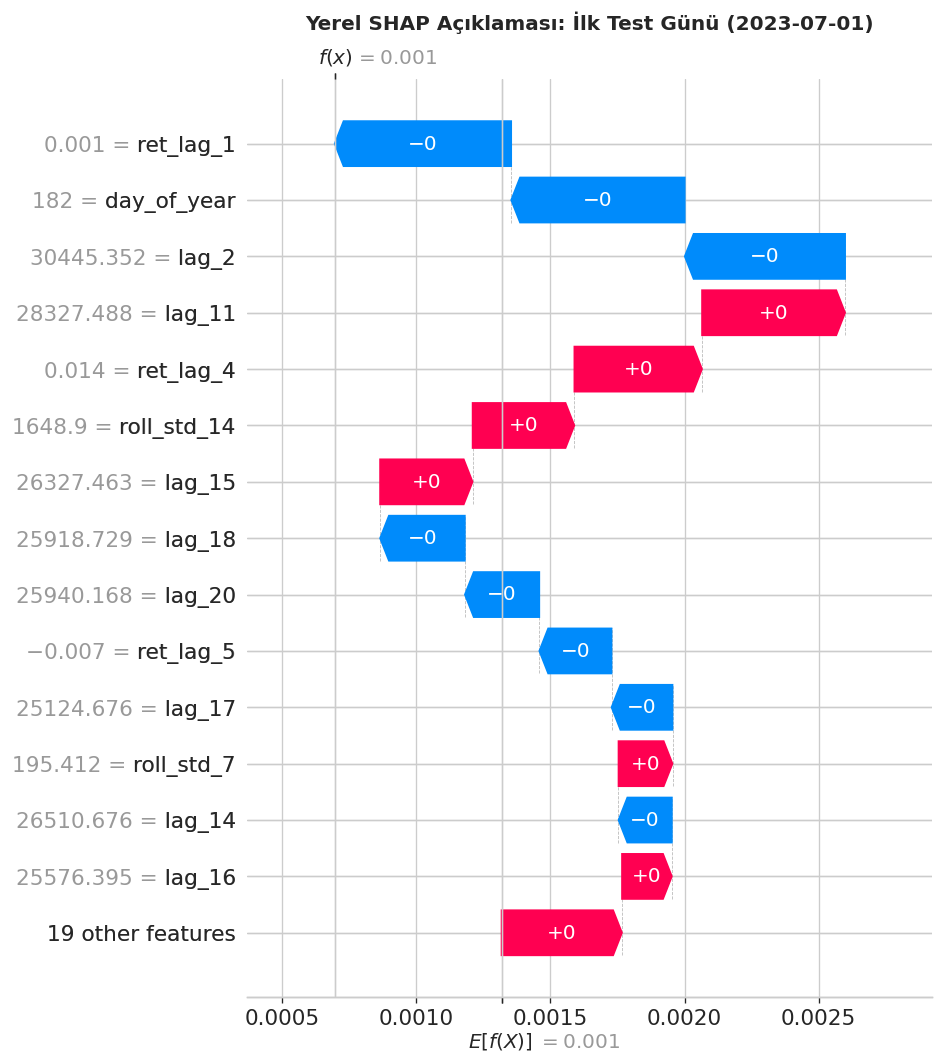

  ✅ İlk Test Günü (2023-07-01) — Gerçek: $30,621 | Tahmin: $30,611



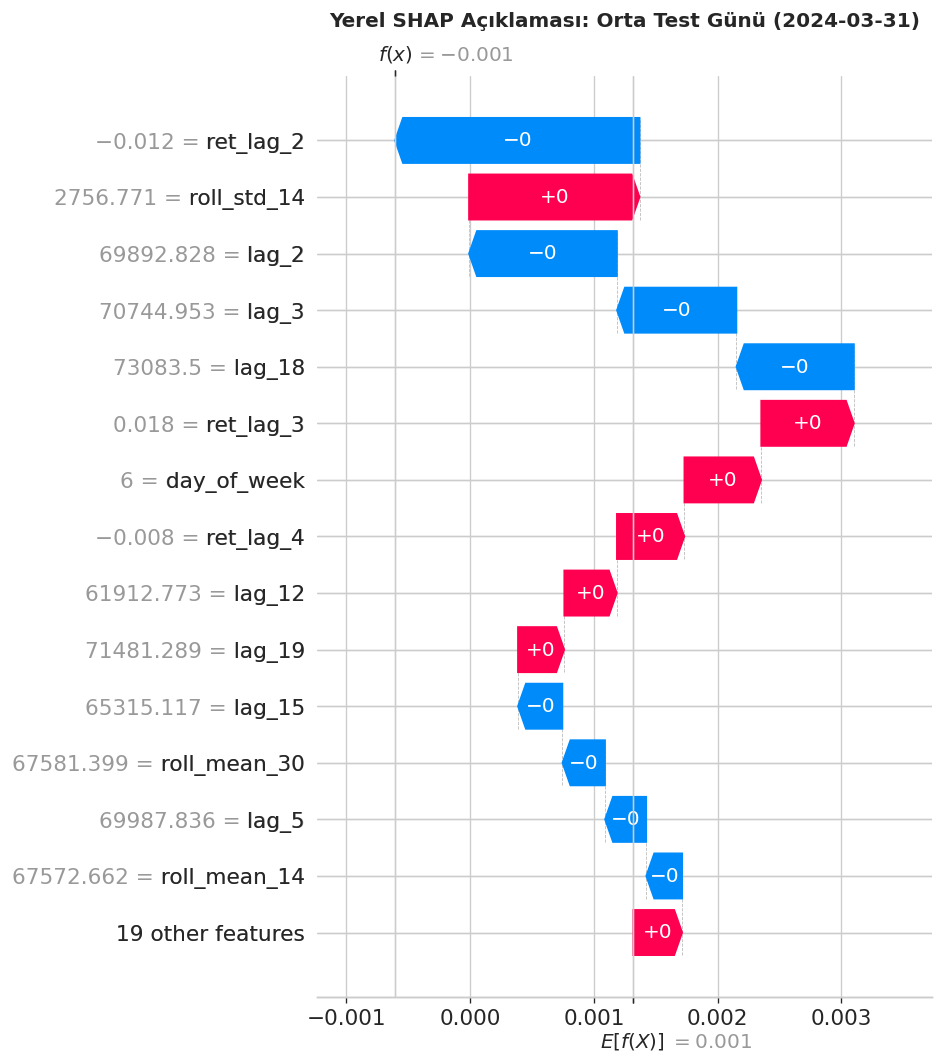

  ✅ Orta Test Günü (2024-03-31) — Gerçek: $69,702 | Tahmin: $71,290



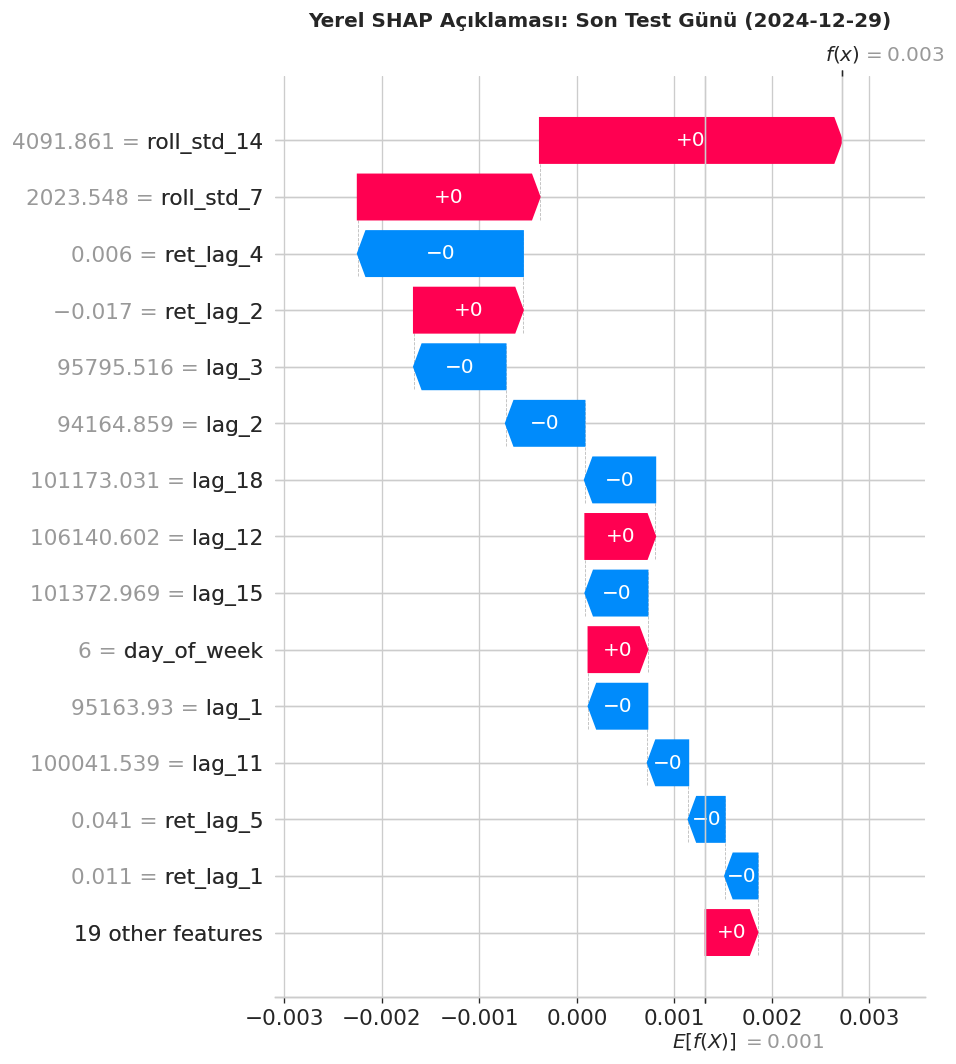

  ✅ Son Test Günü (2024-12-29) — Gerçek: $92,643 | Tahmin: $93,785



In [11]:
# ── Yerel SHAP Açıklaması: Waterfall Plot ─────────────────────────────────────
# Üç farklı test örneği için yerel açıklama üret: ilk, ortadaki, son
sample_indices = [0, len(shap_values)//2, len(shap_values)-1]
sample_labels  = ['İlk Test Günü', 'Orta Test Günü', 'Son Test Günü']

for idx, label in zip(sample_indices, sample_labels):
    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(explanation[idx], max_display=15, show=False)
    date_str = test_df.index[idx].strftime('%Y-%m-%d')
    plt.title(f'Yerel SHAP Açıklaması: {label} ({date_str})', fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()
    plt.savefig(f'/content/shap_waterfall_{idx}.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  ✅ {label} ({date_str}) — Gerçek: ${y_true[idx]:,.0f} | Tahmin: ${y_pred[idx]:,.0f}')
    print()

SHAP Waterfall (Şelale) grafikleri, modelin 'neden bu tahmini yaptım?' sorusuna verdiği en kişiselleştirilmiş cevaptır. Her bir grafik, Bitcoin fiyatının o özel gündeki tahmini için yapılan 'matematiksel tartışmayı' gösterir:

E[f(X)] (Başlangıç Değeri): Grafiğin en altındaki bu değer, modelin elindeki tüm verilerin (eğitim setinin) ortalama tahmini değeridir. Yani model hiçbir özel bilgiye bakmasaydı bu rakamı söyleyecekti.

Kırmızı Çubuklar (+) ve Mavi Çubuklar (-):

Kırmızı Çubuklar: O günkü özelliğin değeri (örneğin dünkü fiyatın çok yüksek olması), modelin beklentisini ortalamadan ne kadar yukarı ittiğini gösterir.
Mavi Çubuklar: O özelliğin (örneğin artan volatilite), tahmini ne kadar aşağı çektiğini gösterir.
f(x) (Sonuç): En üstteki değer, tüm artı ve eksiler toplandıktan sonra modelin ulaştığı nihai tahmindir.

Özellik Değerleri (Sol Taraf): Özellik isimlerinin yanındaki rakamlar (örn. lag_1 = 0.85), o özelliğin o günkü gerçek (normalize) değeridir. Bu, 'Dünkü fiyat 0.85 seviyesindeyken model kararına şu kadar etki etti' şeklinde okunur.

Özetle: Bir waterfall grafiği okurken, hangi özelliğin çubuğunun en uzun olduğuna bakmalısın; o günkü fiyat değişiminin 'başrol oyuncusu' odur.

## 📅 Bölüm 11: Zaman İçinde SHAP Önem Değişimi

Test periyodu boyunca her lag özelliğinin ortalama mutlak SHAP değeri nasıl değişiyor?  
Bu görsel, **modelin geçmişe bakış derinliğinin zaman içinde değişip değişmediğini** ortaya koyar.

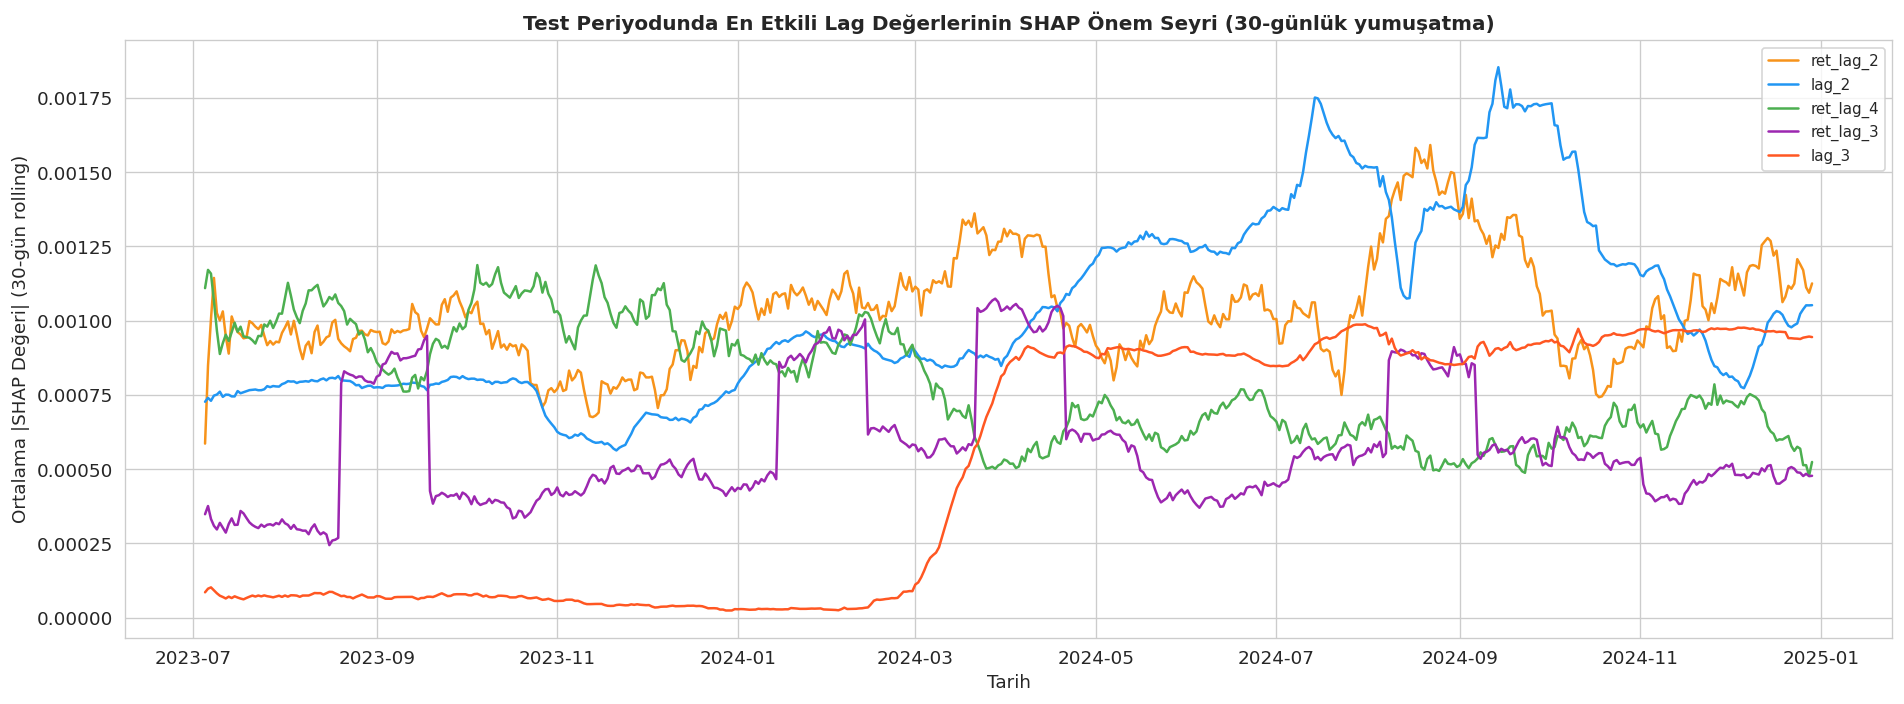

In [12]:
# ── Zaman içinde SHAP önem değişimi (rolling 30-gün) ──────────────────────────
lag_cols_all = [c for c in FEATURE_COLS if c.startswith('lag_') or c.startswith('ret_lag_')]
shap_lag_df  = shap_df[lag_cols_all].abs()

# İlk 5 lag'i çiz
top5_lags = mean_abs_shap[lag_cols_all].nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(16, 6))
colors_t5 = ['#F7931A', '#2196F3', '#4CAF50', '#9C27B0', '#FF5722']

for col, col_c in zip(top5_lags, colors_t5):
    rolling_shap = shap_lag_df[col].rolling(30, min_periods=5).mean()
    ax.plot(shap_lag_df.index, rolling_shap, label=col, color=col_c, linewidth=1.5)

ax.set_title('Test Periyodunda En Etkili Lag Değerlerinin SHAP Önem Seyri (30-günlük yumuşatma)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Ortalama |SHAP Değeri| (30-gün rolling)')
ax.set_xlabel('Tarih')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('/content/shap_temporal.png', bbox_inches='tight', dpi=150)
plt.show()

Modelin Odak Değişimi (Dynamic Attention): Grafikte çizgilerin birbirini kestiğini veya yükselip alçaldığını göreceksin. Bu, modelin her zaman aynı geçmiş güne güvenmediğini kanıtlar. Örneğin, piyasa çok sakinken lag_1 (dün) en önemliyken, sert bir düşüşün ardından roll_std (volatilite) veya lag_7 gibi daha uzak göstergelerin önemi artabilir.

Kalıcı vs. Geçici Önem: Bazı özelliklerin çizgisi grafik boyunca hep en üstte kalabilir. Bu, o özelliğin (genellikle dünkü fiyat veya dünkü getiri) piyasa koşullarından bağımsız olarak modelin 'vazgeçilmez pusulası' olduğunu gösterir.

Regime Göre Duyarlılık: Grafikteki ani yükselişler (peak), o dönemde Bitcoin piyasasında 'olağanüstü' bir durum yaşandığını işaret eder. Eğer bir lag değerinin önemi o bölgede zıplama yapıyorsa, model o spesifik geçmiş günün bilgisini kullanarak mevcut kaosu anlamlandırmaya çalışıyor demektir.

30 Günlük Yumuşatma (Smoothing): Kodda kullanılan rolling(30) ifadesi, günlük gürültüyü temizleyerek bize ana eğilimi gösterir. Eğer bir çizgi istikrarlı bir şekilde yukarı tırmanıyorsa, modelin o veriye olan güveninin (öğrenme sürecinin veya piyasa yapısının değişmesiyle) arttığını anlarız.

Özetle: Bu grafik bize modelin sabit bir formül değil, zamanın ruhuna göre ağırlıklarını güncelleyen esnek bir mekanizma olduğunu matematiksel olarak kanıtlar.

## 🧩 Bölüm 12: Geçmiş Zaman Aralıklarını Gruplama ile Açıklama

Bu bölümde tek tek `lag_1`, `lag_2` gibi özelliklerin yanında, geçmişin hangi **zaman bloklarının** tahmini daha çok etkilediği özetlenir. Amaç, SHAP sonuçlarını daha yorumlanabilir bir yapıya dönüştürmektir: çok yakın geçmiş, yakın geçmiş, orta vadeli geçmiş ve daha eski geçmiş ayrı ayrı analiz edilir.


📌 Grup bazlı SHAP özeti:


,Ortalama |SHAP|,Pay (%)
Gecikmeli getiriler,0.0030,25.0700
Yuvarlanan istatistikler,0.0029,23.6814
Çok yakın geçmiş (1-3),0.0018,14.7141
Eski geçmiş (15-20),0.0017,14.2235
Orta vadeli geçmiş (8-14),0.0014,11.8955
Takvim özellikleri,0.0008,6.7464
Yakın geçmiş (4-7),0.0004,3.6690


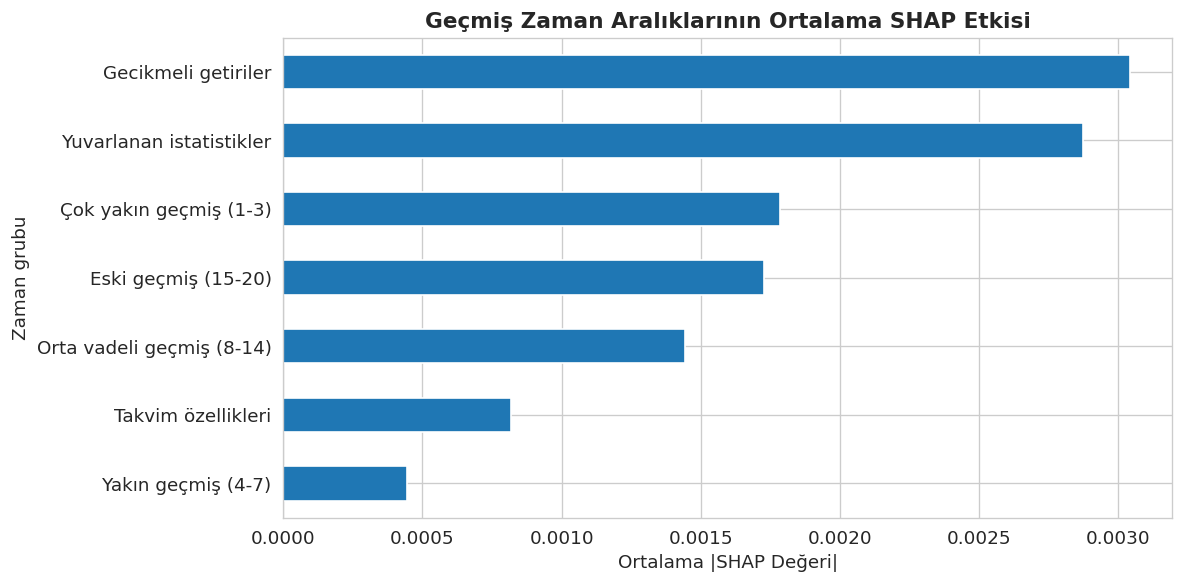

✅ En etkili zaman grubu: Gecikmeli getiriler (%25.1)


In [13]:
# ── Geçmiş zaman blokları bazında SHAP analizi ───────────────────────────────
def feature_group(col: str) -> str:
    """Özellik adını zaman bloğu / özellik türü grubuna eşleştirir."""
    if col.startswith('lag_'):
        lag = int(col.split('_')[1])
        if lag <= 3:
            return 'Çok yakın geçmiş (1-3)'
        elif lag <= 7:
            return 'Yakın geçmiş (4-7)'
        elif lag <= 14:
            return 'Orta vadeli geçmiş (8-14)'
        else:
            return 'Eski geçmiş (15-20)'
    elif col.startswith('ret_lag_'):
        return 'Gecikmeli getiriler'
    elif col.startswith('roll_mean_') or col.startswith('roll_std_'):
        return 'Yuvarlanan istatistikler'
    elif col in ['day_of_week', 'month', 'day_of_year']:
        return 'Takvim özellikleri'
    else:
        return 'Diğer'

# Özellik -> grup eşlemesi
group_map = {col: feature_group(col) for col in FEATURE_COLS}

# SHAP değerlerini grup bazında birleştir
grouped_shap_df = pd.DataFrame(index=shap_df.index)

for group in sorted(set(group_map.values())):
    cols = [c for c in FEATURE_COLS if group_map[c] == group]
    grouped_shap_df[group] = shap_df[cols].abs().sum(axis=1)

# Global grup önemleri
group_importance = grouped_shap_df.mean().sort_values(ascending=False)
group_share = 100 * group_importance / group_importance.sum()

print('📌 Grup bazlı SHAP özeti:')
display(pd.DataFrame({
    'Ortalama |SHAP|': group_importance,
    'Pay (%)': group_share
}).round(4))

# Grafik
plt.figure(figsize=(10, 5))
group_importance.sort_values().plot(kind='barh')
plt.title('Geçmiş Zaman Aralıklarının Ortalama SHAP Etkisi', fontsize=13, fontweight='bold')
plt.xlabel('Ortalama |SHAP Değeri|')
plt.ylabel('Zaman grubu')
plt.tight_layout()
plt.show()

# Kısa yorum için en güçlü grup
top_group = group_importance.index[0]
top_group_share = group_share.loc[top_group]
print(f'✅ En etkili zaman grubu: {top_group} (%{top_group_share:.1f})')

### 📊 Zaman ve Özellik Grupları Detaylı Analizi

Modelin tahmin kararlarını verirken kullandığı veri gruplarının işlevleri şunlardır:

*   **Gecikmeli Getiriler (Lagged Returns):** Son 5 günlük kâr/zarar oranlarını temsil eder. Modelin 'momentum' sensörüdür; Bitcoin'in yarınki hareketinin bugünkü getiri ivmesine ne kadar bağlı olduğunu ölçer.
*   **Çok Yakın Geçmiş (1-3 Gün):** Son 72 saatteki ham fiyat seviyeleridir. Dünkü fiyatın bugün için ne kadar güçlü bir referans noktası oluşturduğunu belirler.
*   **Yakın Geçmiş (4-7 Gün):** Yaklaşık bir haftalık periyodu kapsayarak piyasadaki haftalık döngüleri ve kısa vadeli trend başlangıçlarını kontrol eder.
*   **Yuvarlanan İstatistikler (Rolling Stats):** 7, 14 ve 30 günlük hareketli ortalamalar ve volatiliteyi içerir. Modelin geniş resme bakarak fiyatın ortalamadan sapmalarını (örneğin tepki yükselişlerini) yakalamasını sağlar.
*   **Orta Vadeli Geçmiş (8-14 Gün):** İki haftalık fiyat hafızasıdır; daha yavaş gelişen yapısal trend değişimlerini izler.
*   **Eski Geçmiş (15-20 Gün):** Modelin en uzak hafızasıdır. Etkisi genelde düşüktür; ancak payı arttığında piyasada aylık döngülerin baskın olduğunu gösterir.
*   **Takvim Özellikleri:** Haftanın günü veya yılın ayı gibi periyodik bilgilerdir. 'Hafta sonu etkisi' veya mevsimsel ralli kalıplarını analiz eder.

**Özetle:** Bu grafik, modelin Bitcoin fiyatını öngörürken 'Hangi zaman dilimindeki bilgiye daha çok güvenmeliyim?' sorusuna verdiği ağırlıklı cevabı temsil eder.

## 📊 Bölüm 13: Genel Sonuç Özeti

Tüm bulgular özetlenir ve yorumlanır.

In [14]:
# ── Özet Tablo ────────────────────────────────────────────────────────────────
print('=' * 60)
print('           📋 PROJE ÖZET TABLOSU')
print('=' * 60)
print(f'  Veri Seti    : BTC-USD (yfinance, 2019–2024)')
print(f'  Model        : LightGBM (Gradient Boosted Trees)')
print(f'  XAI Yöntemi  : SHAP TreeExplainer')
print(f'  Lag sayısı   : {N_LAGS}')
print(f'  Eğitim örneği: {len(X_train)}')
print(f'  Test örneği  : {len(X_test)}')
print('-' * 60)
print(f'  RMSE  : ${rmse:>12,.2f}')
print(f'  MAE   : ${mae:>12,.2f}')
print(f'  MAPE  : {mape:>12.2f}%')
print(f'  R²    : {r2:>13.4f}')
print('-' * 60)

print('\n  🔍 SHAP Bulguları:')
print(f'  En etkili özellik: {mean_abs_shap.index[0]}')
print(f'  En etkili 5 özellik: {list(mean_abs_shap.head(5).index)}')

# Lag dağılım özeti
lag_shap_series = mean_abs_shap[[c for c in mean_abs_shap.index if c.startswith('lag_')]]
total_lag_shap  = lag_shap_series.sum()
total_shap      = mean_abs_shap.sum()

print(f'  Tüm lag+ret_lag katkısı: %{100*mean_abs_shap[lag_cols_all].sum()/mean_abs_shap.sum():.1f}')
print(f'  En güçlü zaman grubu   : {group_importance.index[0]} (%{group_share.iloc[0]:.1f})')
print()

top3_lag_pct = lag_shap_series.nlargest(3).sum() / total_shap * 100
top3_lags    = lag_shap_series.nlargest(3).index.tolist()
print(f'  İlk 3 lag ({top3_lags}) toplam katkısı: %{top3_lag_pct:.1f}')

           📋 PROJE ÖZET TABLOSU
  Veri Seti    : BTC-USD (yfinance, 2019–2024)
  Model        : LightGBM (Gradient Boosted Trees)
  XAI Yöntemi  : SHAP TreeExplainer
  Lag sayısı   : 20
  Eğitim örneği: 1612
  Test örneği  : 548
------------------------------------------------------------
  RMSE  : $    1,617.27
  MAE   : $    1,057.52
  MAPE  :         1.81%
  R²    :        0.9936
------------------------------------------------------------

  🔍 SHAP Bulguları:
  En etkili özellik: roll_std_14
  En etkili 5 özellik: ['roll_std_14', 'roll_std_7', 'ret_lag_2', 'lag_2', 'ret_lag_4']
  Tüm lag+ret_lag katkısı: %69.6
  En güçlü zaman grubu   : Gecikmeli getiriler (%25.1)

  İlk 3 lag (['lag_2', 'lag_3', 'lag_18']) toplam katkısı: %17.0


In [15]:
!pip install -q gradio

In [16]:
import gradio as gr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def btc_prediction_dashboard():
    # Test tarihlerini liste olarak al
    available_dates = test_df.index.strftime('%Y-%m-%d').tolist()

    def get_prediction_data(date_str=None):
        if date_str is None:
            idx = np.random.randint(0, len(X_test_scaled))
        else:
            idx = available_dates.index(date_str)

        sample = X_test_scaled[idx].reshape(1, -1)

        # Model Tahmini
        pred_ret = model.predict(sample)[0]
        curr_price = test_df['close'].iloc[idx]
        actual_price = test_df[PRICE_COL].iloc[idx]
        pred_price = curr_price * np.exp(pred_ret)
        final_date = test_df.index[idx].strftime('%Y-%m-%d')

        # SHAP Değerleri
        sv = explainer.shap_values(sample)[0]
        top_indices = np.argsort(np.abs(sv))[-8:][::-1]

        # Görselleştirme
        fig, ax = plt.subplots(figsize=(10, 5))
        features = [FEATURE_COLS[i] for i in top_indices]
        impacts = [sv[i] for i in top_indices]
        colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in impacts]

        y_pos = np.arange(len(features))
        ax.barh(y_pos, impacts, color=colors, align='center', alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features)
        ax.invert_yaxis()
        ax.set_title(f'SHAP Faktör Analizi ({final_date})', fontweight='bold')
        ax.set_xlabel('Fiyat Üzerindeki Etki Gücü (Log-Return Scale)')
        plt.axvline(0, color='black', lw=1, ls='--')
        plt.tight_layout()

        # Durum Kartı Hazırlama
        direction = "📈 YÜKSELİŞ" if pred_ret > 0 else "📉 DÜŞÜŞ"
        perf = "✅ BAŞARILI" if (pred_ret > 0 and (actual_price > curr_price)) or (pred_ret < 0 and (actual_price < curr_price)) else "❌ YANILTIICI"

        summary = f"""
        ### 🔍 Analiz Özeti: {final_date}
        | Değişken | Değer |
        | :--- | :--- |
        | **Mevcut Fiyat** | ${curr_price:,.2f} |
        | **Hedef Tahmin** | ${pred_price:,.2f} |
        | **Beklenen Yön** | {direction} |
        | **Gerçekleşen** | ${actual_price:,.2f} |
        | **Hata Payı** | ${abs(actual_price - pred_price):,.2f} |
        | **Yön İisabeti** | {perf} |
        """

        return summary, fig

    with gr.Blocks(theme=gr.themes.Default(primary_hue="orange", secondary_hue="blue")) as demo:
        gr.Markdown("# 🚀 Bitcoin XAI Gelişmiş Tahmin Sistemi")

        with gr.Tabs():
            with gr.TabItem("🎯 Tekil Gün Analizi"):
                with gr.Row():
                    with gr.Column(scale=1):
                        date_input = gr.Dropdown(choices=available_dates, label="Analiz Edilecek Tarihi Seçin", value=available_dates[-1])
                        btn_rand = gr.Button("🎲 Rastgele Gün Getir", variant="secondary")
                        output_text = gr.Markdown()

                    with gr.Column(scale=2):
                        output_plot = gr.Plot()

            with gr.TabItem("📊 Model Performans Özeti"):
                gr.Markdown("### Test Seti Genel Metrikleri")
                gr.HTML(f"""
                <div style='display: flex; justify-content: space-around; background: #f8f9fa; padding: 20px; border-radius: 10px;'>
                    <div style='text-align: center;'><b>MAPE</b><br><span style='font-size: 24px; color: #2196F3;'>{mape:.2f}%</span></div>
                    <div style='text-align: center;'><b>R² Skoru</b><br><span style='font-size: 24px; color: #4CAF50;'>{r2:.4f}</span></div>
                    <div style='text-align: center;'><b>MAE</b><br><span style='font-size: 24px; color: #FF9800;'>${mae:,.0f}</span></div>
                </div>
                """)
                gr.Image("/content/prediction_plot.png", label="Tahmin vs Gerçek Grafiği")

        # Event Listeners
        date_input.change(fn=get_prediction_data, inputs=date_input, outputs=[output_text, output_plot])
        btn_rand.click(fn=lambda: get_prediction_data(None), outputs=[output_text, output_plot])

    return demo

if __name__ == "__main__":
    dashboard = btc_prediction_dashboard()
    dashboard.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://da51c1af609dd8bcc1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://da51c1af609dd8bcc1.gradio.live
